In [ ]:
# A dependency of the preprocessing for BERT inputs
!pip3 install tensorflow-text

In [ ]:
#to solve depndency issue for tf-models-official
!pip install numba

In [ ]:
!pip install tf-models-official

In [ ]:
!pip install transformers

In [ ]:
import os
import shutil

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization  # to create AdamW optimizer

import matplotlib.pyplot as plt

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
upload = files.upload()

Saving IDTATextPreprocessing.csv to IDTATextPreprocessing (1).csv


In [ ]:
reviews = pd.read_csv("IDTATextPreprocessing (1).csv")

In [ ]:
reviews.head()

,Unnamed: 0,Review,Sentiment
0,0,way plug u unless go converter,0
1,1,good case excellent value,1
2,2,great jawbone,1
3,3,tie charger conversation last minutesmajor pro...,0
4,4,mic great,1


In [ ]:
reviews.shape

(1000, 3)

In [ ]:
#save the labels and encode them as 1 and 0 for future classification/clustering
from sklearn.preprocessing import LabelEncoder

enc = LabelEncoder()
label = enc.fit_transform(reviews['Sentiment'])
print(label[:10])
print(reviews['Sentiment'][:10])

[0 1 1 0 1 0 0 1 0 0]
0    0
1    1
2    1
3    0
4    1
5    0
6    0
7    1
8    0
9    0
Name: Sentiment, dtype: int64


In [ ]:
reviews1 = list(zip(reviews['Review'], label))

reviews1 = pd.DataFrame (reviews1, columns = ['Review', 'Sentiment'])
reviews1

,Review,Sentiment
0,way plug u unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tie charger conversation last minutesmajor pro...,0
4,mic great,1
...,...,...
995,screen get smudge easily touch ear face,0
996,piece junk lose call phone,0
997,item match picture,0
998,thing disappoint infra red port irda,0


In [ ]:
#may be worth shuffeling the data to prevent any ordering having an influence on the performance

reviews1 = reviews1.sample(frac=1, random_state=1)
reviews1.reset_index(drop=True, inplace=True)

In [ ]:
reviews1.head()

,Review,Sentiment
0,holster arrive match photo ad,0
1,doesnt job,0
2,colleague get great receptiona little expensiv...,1
3,love phone,1
4,bad customer service ever,0


In [ ]:
from sklearn.model_selection import train_test_split

#split and take the test set
X, X_test, y, y_test = (train_test_split(reviews1['Review'], reviews1['Sentiment'],
                                                     stratify=reviews1['Sentiment'],
                                                     test_size=0.2,
                                                     train_size=0.8
                                                     ))



In [ ]:
#split the train set (X) into train and validation
X_train, X_val, y_train, y_val = (train_test_split(X, y,
                                                     stratify=y,
                                                     test_size=0.25,
                                                     train_size=0.75
                                                     ))

In [ ]:
X_train

450    instruction didnt explain microphone jack coul...
449                   welldesigned sharp blue nice color
20     come strong light use light camera shot even f...
962                                     phone work great
744                        bought mother problem battery
                             ...                        
447    headphone great find think perhaps best purcha...
666                                  great product price
103                      nice quality build unlike cheap
398    camera phone may use dustpan indoors id rather...
482                              excellent product price
Name: Review, Length: 600, dtype: object

In [ ]:
X_val

808         checked everywhere feature really disappoint
255                                        windresistant
260                       could get strong enough signal
950                                one didnt work either
838    would definitely recommend jabra btv look comf...
                             ...                        
806                                     also new problem
756                                          comfortable
719                      barely ever hear constantly say
32         like loud buzzing override conversation phone
532                          would recommend item anyone
Name: Review, Length: 200, dtype: object

In [ ]:
X_test

565                                            never get
245    bad piece crap ever along verizon customer ser...
658    uncomfortable sound quality quite poor compare...
89                              noise shield incrediable
754                           purcashed car charger work
                             ...                        
958                                          love device
396    give wirefly stari contact cingularatt inform ...
389                                doesnt make look cool
88                                                 happy
875                               good product well make
Name: Review, Length: 200, dtype: object

In [ ]:
#@title Choose a BERT model to fine-tune

#the model has 5 layers (L), 512 hidden size H and 8 attention heads
bert_model_name = 'small_bert/bert_en_uncased_L-4_H-512_A-8'

map_name_to_handle = {
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1',
}

map_model_to_preprocess = {
    'small_bert/bert_en_uncased_L-4_H-512_A-8':
        'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3',
}

tfhub_handle_encoder = map_name_to_handle[bert_model_name]
tfhub_handle_preprocess = map_model_to_preprocess[bert_model_name]

print(f'BERT model selected           : {tfhub_handle_encoder}')
print(f'Preprocess model auto-selected: {tfhub_handle_preprocess}')

BERT model selected           : https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Preprocess model auto-selected: https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3


In [ ]:
bert_preprocess_model = hub.KerasLayer(tfhub_handle_preprocess)

In [ ]:
reviews1['Review'][0]

'holster arrive match photo ad'

In [ ]:
text_test = ["holster arrive match photo ad"]
text_preprocessed = bert_preprocess_model(text_test)

print(f'Keys       : {list(text_preprocessed.keys())}')
print(f'Shape      : {text_preprocessed["input_word_ids"].shape}')
print(f'Word Ids   : {text_preprocessed["input_word_ids"][0, :12]}')
print(f'Input Mask : {text_preprocessed["input_mask"][0, :12]}')
print(f'Type Ids   : {text_preprocessed["input_type_ids"][0, :12]}')

Keys       : ['input_mask', 'input_word_ids', 'input_type_ids']
Shape      : (1, 128)
Word Ids   : [  101 29447  7180  2674  6302  4748   102     0     0     0     0     0]
Input Mask : [1 1 1 1 1 1 1 0 0 0 0 0]
Type Ids   : [0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
bert_model = hub.KerasLayer(tfhub_handle_encoder)

In [ ]:
bert_results = bert_model(text_preprocessed)

print(f'Loaded BERT: {tfhub_handle_encoder}')
print(f'Pooled Outputs Shape:{bert_results["pooled_output"].shape}')
print(f'Pooled Outputs Values:{bert_results["pooled_output"][0, :12]}')
print(f'Sequence Outputs Shape:{bert_results["sequence_output"].shape}')
print(f'Sequence Outputs Values:{bert_results["sequence_output"][0, :12]}')

Loaded BERT: https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Pooled Outputs Shape:(1, 512)
Pooled Outputs Values:[ 9.8352414e-01  8.4892285e-01 -1.4618691e-04 -2.3501968e-01
  1.1816764e-01  7.3622042e-01  9.9984992e-01 -9.9928236e-01
 -2.4574423e-01 -8.3999145e-01 -1.5340745e-01 -9.3929213e-01]
Sequence Outputs Shape:(1, 128, 512)
Sequence Outputs Values:[[ 3.6711511e-01 -5.0624859e-02  6.4347315e-01 ... -1.5647112e+00
   1.1748857e+00  9.2456776e-01]
 [-7.3170602e-02  1.4077947e-03  3.8115287e-01 ... -1.9794658e-01
   3.6356885e-02  9.1134435e-01]
 [-2.6266512e-02  2.4807137e-01  6.1592156e-01 ... -1.0051202e+00
   4.1546011e-01  5.1650834e-01]
 ...
 [ 2.4244370e-01  2.0011237e-01  2.7378517e-01 ... -7.7115041e-01
   1.0829004e+00  7.4597991e-01]
 [ 6.5258455e-01  3.9992325e-02  3.9573869e-01 ... -6.7244804e-01
   1.2333239e+00  6.3708341e-01]
 [ 5.9935176e-01 -8.5248642e-02  4.5015928e-01 ... -4.5933232e-01
   8.4846473e-01  5.3720731e-01]]


In [ ]:
def build_classifier_model():
  text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text')
  preprocessing_layer = hub.KerasLayer(tfhub_handle_preprocess, name='preprocessing')
  encoder_inputs = preprocessing_layer(text_input)
  encoder = hub.KerasLayer(tfhub_handle_encoder, trainable=True, name='BERT_encoder')
  outputs = encoder(encoder_inputs)
  net = outputs['pooled_output']
  net = tf.keras.layers.Dropout(0.1)(net)
  #net = tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')(net)
  net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
  return tf.keras.Model(text_input, net)

In [ ]:
classifier_model = build_classifier_model()

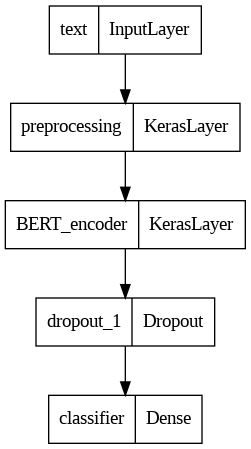

In [ ]:
tf.keras.utils.plot_model(classifier_model)

In [ ]:
epochs = 6
steps_per_epoch = 1200  #corresponding to the train set size
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1*num_train_steps) #10% of num_train_steps

init_lr = 3e-5
optimizer = optimization.create_optimizer(init_lr=init_lr,
                                          num_train_steps=num_train_steps,
                                          num_warmup_steps=num_warmup_steps,
                                          optimizer_type='adamw')

In [ ]:
#fine-tune BERT for classification
classifier_model.compile(optimizer,
                     loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                     metrics=[tf.keras.metrics.BinaryAccuracy()])
classifier_model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text (InputLayer)           [(None,)]                    0         []                            
                                                                                                  
 preprocessing (KerasLayer)  {'input_word_ids': (None,    0         ['text[0][0]']                
                             128),                                                                
                              'input_type_ids': (None,                                            
                             128),                                                                
                              'input_mask': (None, 128)                                           
                             }                                                              

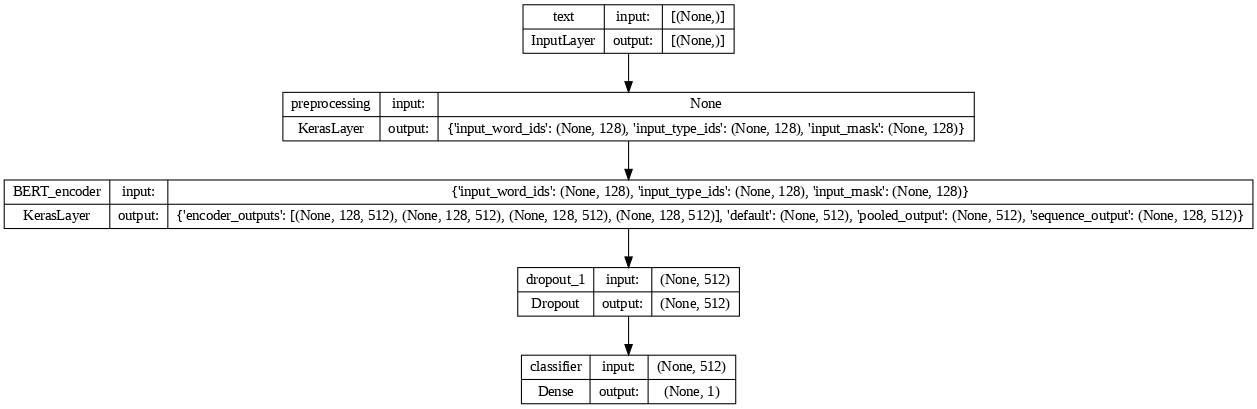

In [ ]:
tf.keras.utils.plot_model(model=classifier_model,show_shapes=True,dpi=76)

In [ ]:
print(f'Training model with {tfhub_handle_encoder}')
history = classifier_model.fit(X_train,
                               y_train,
                               validation_data=(X_val, y_val),
                               epochs=epochs)

Training model with https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1
Epoch 1/6
19/19 [==============================] - 197s 10s/step - loss: 0.7834 - binary_accuracy: 0.5150 - val_loss: 0.7613 - val_binary_accuracy: 0.5100
Epoch 2/6
19/19 [==============================] - 186s 10s/step - loss: 0.7454 - binary_accuracy: 0.5250 - val_loss: 0.7172 - val_binary_accuracy: 0.5450
Epoch 3/6
19/19 [==============================] - 185s 10s/step - loss: 0.6928 - binary_accuracy: 0.5583 - val_loss: 0.6932 - val_binary_accuracy: 0.5400
Epoch 4/6
19/19 [==============================] - 185s 10s/step - loss: 0.6779 - binary_accuracy: 0.5650 - val_loss: 0.6625 - val_binary_accuracy: 0.5800
Epoch 5/6
19/19 [==============================] - 185s 10s/step - loss: 0.6687 - binary_accuracy: 0.5650 - val_loss: 0.6239 - val_binary_accuracy: 0.6250
Epoch 6/6
19/19 [==============================] - 193s 10s/step - loss: 0.6055 - binary_accuracy: 0.6683 - val_loss: 0.5879 - val_bi

dict_keys(['loss', 'binary_accuracy', 'val_loss', 'val_binary_accuracy'])


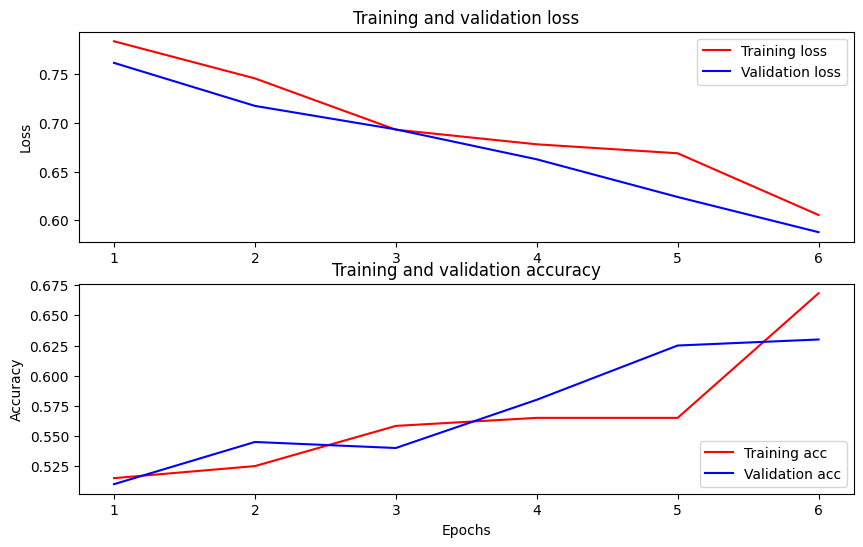

In [ ]:
history_dict = history.history
print(history_dict.keys())

acc = history_dict['binary_accuracy']
val_acc = history_dict['val_binary_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)
fig = plt.figure(figsize=(10, 6))
fig.tight_layout()

plt.subplot(2, 1, 1)
# r is for "solid red line"
plt.plot(epochs, loss, 'r', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
# plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(epochs, acc, 'r', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [ ]:
loss, accuracy = classifier_model.evaluate(X_test, y_test)

print(f'Loss: {loss}')
print(f'Accuracy: {accuracy}')

7/7 [==============================] - 24s 3s/step - loss: 0.5821 - binary_accuracy: 0.6400
Loss: 0.5821301937103271
Accuracy: 0.6399999856948853


In [ ]:
#performance metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#predicted values using the model
y_pred=classifier_model.predict(X_test)

print(y_pred.flatten())

7/7 [==============================] - 23s 3s/step
[-0.9502065  -0.47112486  0.0368789  -0.5618023   0.20790394  0.73888427
 -0.32122573 -0.99734694 -0.31817788 -0.17122419 -0.6496341  -0.8359183
  0.64177644  0.09829266  0.35900414 -0.5416593   1.4810468   0.00374438
 -0.5835695  -0.52334875  1.3068204   0.26214653 -0.07465616 -0.4442277
  0.13595684 -0.86887246  0.25974822  0.5985141   0.672349   -0.56539536
 -0.06225552  0.88472056 -0.60155666 -0.57387155  0.63753945 -1.0186203
  0.13889162 -0.06931137 -0.91036004  0.20531504 -0.5590988   0.46816632
  1.1017163   0.5977079  -0.3942675  -1.3899939  -0.49382174 -0.24227352
 -0.5917845   1.2716421   0.4562233  -0.5193662  -0.40709752 -0.8467501
  0.0217696  -0.5966842   0.1781147  -0.6240692  -0.7880077  -1.1487333
  0.82336056  0.88897943 -0.11930056  0.19267602 -0.5290033  -0.578745
 -0.2946486   0.2355888  -0.17294784  0.3224311  -1.0578498   0.05915385
  0.67645776 -0.20818521  1.037075    0.7428847  -0.6259619  -0.558841
 -0.69163

In [ ]:
#len(y_pred)

for i in range(len(y_pred)):
  if y_pred[i]<0.5:
    y_pred[i] = 0
  else: y_pred[i] = 1

print(y_pred.flatten())

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0.
 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.
 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 1.]


In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score

print(confusion_matrix(y_test, y_pred), '\n')
#print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
#print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
#print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)), '\n')

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))

[[92  8]
 [64 36]] 

              precision    recall  f1-score   support

           0       0.59      0.92      0.72       100
           1       0.82      0.36      0.50       100

    accuracy                           0.64       200
   macro avg       0.70      0.64      0.61       200
weighted avg       0.70      0.64      0.61       200

Accuracy: 0.64
AUC: 0.6399999999999999
